### Content: 
Given the presence of ID identifying the vehicles in the `tripsv3_cleaned.parquet` dataset, one can study how each e-scooter is used; for instance, one can check the cumulative time of usage of each vehicle and if there are patterns in the trajectory a given e-scooter does, which may suggest it is underused.

In [2]:
import pandas as pd
import numpy as np
from shapely.geometry import Point
import seaborn as sns

In [3]:
data = pd.read_parquet('data/tripsv3_cleaned.parquet')

In [4]:
data.head(2)

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31


In [5]:
len(data.trip_vehicle_id.unique()) # 645 different scooters available 

645

In [6]:
# start_pt = []
# end_pt = []
# for pt in range(len(data)):
#     start_pt.append(Point(data.trip_origin_longitude[pt], data.trip_origin_latitude[pt]))
#     end_pt.append(Point(data.trip_destination_longitude[pt], data.trip_destination_latitude[pt]))
# data['start_pt'] = start_pt
# data['end_pt'] = end_pt

### Cumulative time of usage per e-scooter

In [43]:
duration = []
for r in range(len(data)):
    duration.append(data.trip_end[r]-data.trip_start[r])
data['duration'] = duration

In [44]:
# cumulative run time for each vehicle
drtn_by_v = data.groupby(['trip_vehicle_id'])['duration'].agg(["sum"]).reset_index()
drtn_by_v.columns = ['trip_vehicle_id', 'cumduration']
drtn_by_v.head()

,trip_vehicle_id,cumduration
0,126589,0 days 05:04:04
1,126637,0 days 04:31:09
2,126682,0 days 05:42:20
3,127093,0 days 07:44:29
4,127115,0 days 07:12:42


In [45]:
drtn_by_v['cumduration'].max() # 6 days 12 h 13 min 02 sec

Timedelta('6 days 12:13:02')

In [46]:
drtn_by_v['cumduration'].min() # 6 min 49 sec ?!?!?!?!

Timedelta('0 days 00:06:49')

In [47]:
drtn_by_v[drtn_by_v['cumduration']==drtn_by_v['cumduration'].min()]

,trip_vehicle_id,cumduration
345,3S5078,0 days 00:06:49


In [48]:
drtn_by_v.sort_values(by=['cumduration'])

,trip_vehicle_id,cumduration
345,3S5078,0 days 00:06:49
384,3s140,0 days 00:08:00
263,3S4270,0 days 00:10:23
418,3s2135,0 days 00:13:39
144,158286,0 days 00:19:30
...,...,...
304,3S4675,5 days 03:11:56
478,3s3028,5 days 09:58:19
276,3S4339,6 days 04:42:23
228,3S3971,6 days 05:49:12


In [49]:
drtn_by_v['cumduration'].mean()  
# average usage of an e-scooter (from 2020 to March 2022): 1 day 2 h 23 min 45 sec
# maybe some e-scooters are added later in time, not all made available since the beginning of 2020

Timedelta('1 days 02:23:45.125581395')

In [51]:
### USAGE IN 2022 ONLY
y=[]
for r in range(len(data)):
    y.append(data.trip_start[r].year)
data['year']=y
df = data[data.year == 2022]
# cumulative run time for each vehicle
drtn_by_v = df.groupby(['trip_vehicle_id'])['duration'].agg(["sum"]).reset_index()
drtn_by_v.columns = ['trip_vehicle_id', 'cumduration']
drtn_by_v.head()

,trip_vehicle_id,cumduration
0,126589,0 days 05:04:04
1,126637,0 days 04:31:09
2,126682,0 days 05:42:20
3,127093,0 days 07:44:29
4,127115,0 days 07:12:42


In [57]:
print('Minimum:',drtn_by_v['cumduration'].min(), 
    '\nMaximum:', drtn_by_v['cumduration'].max(), 
    '\nMean:', drtn_by_v['cumduration'].mean(), 
    '\nMedian:', drtn_by_v['cumduration'].median())

Minimum: 0 days 00:02:09 
Maximum: 2 days 03:41:04 
Mean: 0 days 12:14:27.049853372 
Median: 0 days 07:20:39


### Usage in 2022:

In [42]:
y=[]
for i in range(len(data)):
    y.append(data.trip_start[i].year)
data['year'] = y

In [43]:
data = data[data.year == 2022]

In [ ]:
data = data.reset_index()

In [44]:
len(data.trip_vehicle_id.unique()) # 341 veicoli nel 2022

341

In [45]:
# get bounding box of the area where e-scooters are allowed
# (minx, miny, maxx, maxy)

import shapefile as shp

sf = shp.Reader('data/static/ambito_esercizio_monopattini.shp')
bb = sf.bbox

In [46]:
minx = bb[0] 
miny = bb[1] 
maxx = bb[2] 
maxy = bb[3]

In [47]:
from pyproj import Proj, transform

inProj = Proj(init='epsg:25832', preserve_units=True) # source coordinate system
outProj = Proj(init='epsg:4326') # destination coordinate system

minx, miny = transform(inProj, outProj, minx, miny)
maxx, maxy = transform(inProj, outProj, maxx, maxy)

c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\luisa\AppData\Local\Temp\ipykernel_21220\91068550.py:6: DeprecationWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  minx, miny

In [62]:
import shapely.geometry
import pyproj

# Set up transformers, EPSG:3857 is metric
to_crs_transformer = pyproj.Transformer.from_crs('epsg:4326', 'epsg:3857')
to_original_transformer = pyproj.Transformer.from_crs('epsg:3857', 'epsg:4326')

# Create corners of rectangle to be transformed to a grid
sw = shapely.geometry.Point((minx, miny))
ne = shapely.geometry.Point((maxx, maxy))

stepsize = 2000 # 2 km grid step size

# Project corners to target projection (transform to epsg:3857)
transformed_sw = to_crs_transformer.transform(sw.x, sw.y) 
transformed_ne = to_crs_transformer.transform(ne.x, ne.y)

# Iterate over the area
gridpoints = []
x = transformed_sw[0]
while x < transformed_ne[0]:
    y = transformed_sw[1]
    while y < transformed_ne[1]:
        p = shapely.geometry.Point(to_original_transformer.transform(x, y))
        gridpoints.append(p)
        y += stepsize
    x += stepsize


In [77]:
longlat=[]
long=[]
lat=[]
for p in gridpoints:
    longlat.append([p.x, p.y])
    long.append(p.x)
    lat.append(p.y)
longlat = np.array(longlat)

In [78]:
df = pd.DataFrame(data={'long': long, 'lat': lat})

In [80]:
import geopandas as gpd

df = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df.long, df.lat))

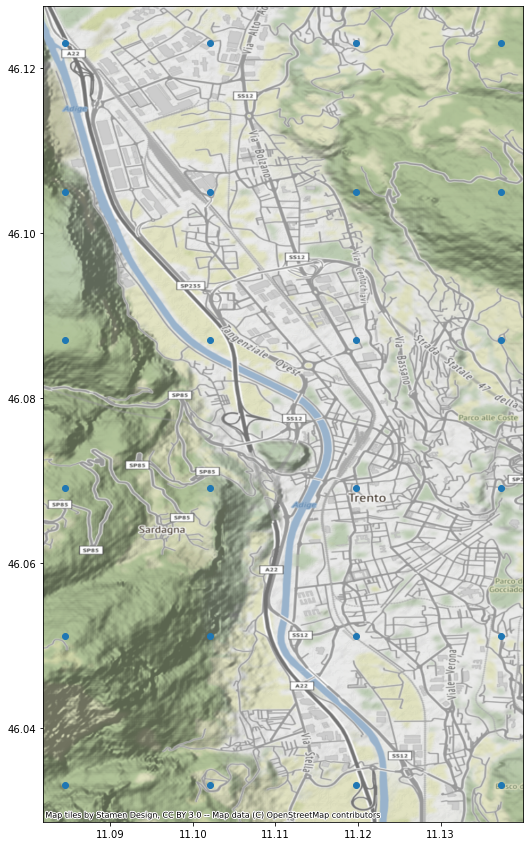

In [107]:
import contextily as ctx

fig, ax = plt.subplots(1, figsize=(20,15)) 

df.to_crs(epsg=4326).plot(ax=ax)

ctx.add_basemap(ax, crs=df.to_crs(epsg=4326).crs.to_string())


In [ ]:
# import matplotlib.pyplot as plt

# plt.hist2d(longlat[:,0], longlat[:,1], bins=50)

In [65]:
def zones(long, lat):
    if long < 11.10: # sx
        if lat < 46.05: 
            return 'bottom_left'
        elif lat >= 46.05 and lat < 46.07: 
            return 'middle-bottom_left'
        elif lat >= 46.07 and lat < 46.09: 
            return 'middle_left'
        elif lat >= 46.09 and lat < 46.11: 
            return 'middle-upper_left'
        else: # > 46.11 
            return 'upper_left'
    elif long < 11.12 and long >= 11.10: # center
        if lat < 46.05: 
            return 'bottom_center'
        elif lat >= 46.05 and lat < 46.07: 
            return 'middle-bottom_center'
        elif lat >= 46.07 and lat < 46.09: 
            return 'middle_center'
        elif lat >= 46.09 and lat < 46.11: 
            return 'middle-upper_center'
        else: # > 46.11 
            return 'upper_center'
    else: # dx
        if lat < 46.05: 
            return 'bottom_right'
        elif lat >= 46.05 and lat < 46.07: 
            return 'middle-bottom_right'
        elif lat >= 46.07 and lat < 46.09: 
            return 'middle_right'
        elif lat >= 46.09 and lat < 46.11: 
            return 'middle-upper_right'
        else: # > 46.11 
            return 'upper_right'

In [ ]:
# less zones

# def zones(long, lat):
#     if long < 11.11: # sx
#         if lat < 46.06: 
#             return 'bottom_left'
#         elif lat >=46.06 and lat <=46.09: 
#             return 'middle_left'
#         else: # > 46.09 
#             return 'upper_left'
#     else: # dx
#         if lat < 46.06: 
#             return 'bottom_right'
#         elif lat >=46.06 and lat <=46.09: 
#             return 'middle_right'
#         else: # > 46.09 
#             return 'upper_right'

In [66]:
z = []
for row in range(len(data)):
    z.append(zones(data.trip_destination_longitude[row], data.trip_destination_latitude[row]))

data['zone'] = z

In [67]:
data.zone.value_counts()

middle-bottom_right     11213
middle-bottom_center     6389
middle_center            4022
middle_right             3748
bottom_right             1922
middle-upper_center      1242
bottom_center              61
middle-upper_left          27
middle-upper_right         16
upper_center                2
upper_left                  1
Name: zone, dtype: int64

In [68]:
cols = ['trip_vehicle_id', 'zone']
colmap = sns.light_palette("green", as_cmap=True)
pd.crosstab(data[cols[0]], data[cols[1]]).style.background_gradient(cmap = colmap)

zone,bottom_center,bottom_right,middle-bottom_center,middle-bottom_right,middle-upper_center,middle-upper_left,middle-upper_right,middle_center,middle_right,upper_center,upper_left
trip_vehicle_id,,,,,,,,,,,
126589,1,1,14,20,2,0,0,2,6,0,0
126637,0,2,10,10,1,0,0,2,2,0,0
126682,0,2,14,9,8,0,0,6,7,0,0
127093,0,2,11,21,0,0,0,5,6,0,0
127115,0,1,19,26,0,0,0,15,7,0,0
127390,0,1,6,27,8,0,0,18,7,0,0
128102,0,2,17,22,5,0,0,19,11,0,0
128277,0,3,15,18,0,0,0,6,1,0,0
128371,0,3,12,29,2,0,0,11,9,0,0
